### 공공데이타 - 건강진단 데이타

#### 주제 : 건강진단 데이터를 활용한 신장과 체중의 상관관계 분석

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

In [10]:
# 공공 데이타 읽어오기
df = pd.read_csv("./data/국민건강보험공단_건강검진정보_2024.CSV", encoding='cp949')

## 데이타 살펴보기

In [6]:
df.shape

(1000000, 33)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   기준년도           1000000 non-null  int64  
 1   가입자일련번호        1000000 non-null  int64  
 2   시도코드           1000000 non-null  int64  
 3   성별코드           1000000 non-null  int64  
 4   연령대코드(5세단위)    1000000 non-null  int64  
 5   신장(5cm단위)      1000000 non-null  int64  
 6   체중(5kg단위)      1000000 non-null  int64  
 7   허리둘레           999505 non-null   float64
 8   시력(좌)          999807 non-null   float64
 9   시력(우)          999808 non-null   float64
 10  청력(좌)          999852 non-null   float64
 11  청력(우)          999852 non-null   float64
 12  수축기혈압          994210 non-null   float64
 13  이완기혈압          994211 non-null   float64
 14  식전혈당(공복혈당)     994153 non-null   float64
 15  총콜레스테롤         342400 non-null   float64
 16  트리글리세라이드       342395 non-null   float64
 17  HDL콜레스테롤       34239

## 1. 결측치 제거 

### 1) 결측치 확인 - isna(), isnull()

In [8]:
df.isna()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
999996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
999997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
999998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False


In [ ]:
#몇개의 결측치가 있는지 확인한다.
df.isna().sum()   

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                 495
시력(좌)                193
시력(우)                192
청력(좌)                148
청력(우)                148
수축기혈압               5790
이완기혈압               5789
식전혈당(공복혈당)          5847
총콜레스테롤            657600
트리글리세라이드          657605
HDL콜레스테롤          657603
LDL콜레스테롤          663611
혈색소                 5855
요단백                11319
혈청크레아티닌             5852
혈청지오티(AST)          5848
혈청지피티(ALT)          5848
감마지티피               5848
흡연상태                 118
음주여부                  45
구강검진수검여부               0
치아우식증유무           654572
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                654572
dtype: int64

In [11]:
#총 결측값
df.isna().sum().sum()

np.int64(7004898)

### 2) 결측치 제거 및 결측치 대체 - fillna(), dropna()

In [12]:
# 모든 결측값을 0으로 처리한다 
df = df.fillna(0) 

In [13]:
df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,...,13.0,6.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,...,10.0,14.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,...,19.0,17.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0
3,2024,3770599,41,1,16,160,70,89.0,1.0,1.0,...,26.0,28.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0
4,2024,2634185,41,1,11,175,65,76.0,1.0,1.0,...,18.0,12.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0


### 3) 결측치 대체 후 확인

In [14]:
df.isna().sum().sum()

np.int64(0)

## 2. 피처 엔지니어링 - 피처 선택 및 새로운 피처 생성 

### 1) 기존 컬럼을 이용해 새로운 데이타프레임 생성

In [17]:
df_new = df [['성별코드','신장(5cm단위)']].copy()
df_new.head()

,성별코드,신장(5cm단위)
0,2,160
1,2,155
2,2,150
3,1,160
4,1,175


In [18]:
df_new.shape

(1000000, 2)

### 2) 새로운 피처(컬럼) 추가 - count  

In [19]:
df_new.loc[:,"count"] = 1  

In [20]:
df_new.head()

,성별코드,신장(5cm단위),count
0,2,160,1
1,2,155,1
2,2,150,1
3,1,160,1
4,1,175,1


In [21]:
df_new.index

RangeIndex(start=0, stop=1000000, step=1)

In [22]:
#새로 만든 count열의 개수를 세워봄
df_new["count"].count()

np.int64(1000000)

### 3) 피봇 테이블 만들기
- 남 여 별로 신장별 통계를 보고 싶음

In [24]:
df_pivot = pd.pivot_table(df_new,
               index=['신장(5cm단위)'],
               columns=['성별코드'],
               values='count',
               aggfunc=np.sum)

In [25]:
df_pivot.tail()

성별코드,1,2
신장(5cm단위),,
175,105261.0,1469.0
180,41647.0,89.0
185,9028.0,7.0
190,1117.0,NaN
195,92.0,NaN


### 4) 결측치 대체

In [26]:
df_pivot = df_pivot.fillna(0)    

In [28]:
df_pivot.tail()

성별코드,1,2
신장(5cm단위),,
175,105261.0,1469.0
180,41647.0,89.0
185,9028.0,7.0
190,1117.0,0.0
195,92.0,0.0


## 3. 기술 통계량 확인

In [29]:
df_pivot.describe() 

성별코드,1,2
count,14.000000,14.000000
mean,36995.000000,34433.571429
std,53374.577322,51258.713404
min,10.000000,0.000000
25%,171.750000,124.500000
50%,6105.500000,4826.000000
75%,56225.500000,50477.750000
max,154038.000000,145832.000000


## 4. 그래프 시각화

### 1) 선형 그래프

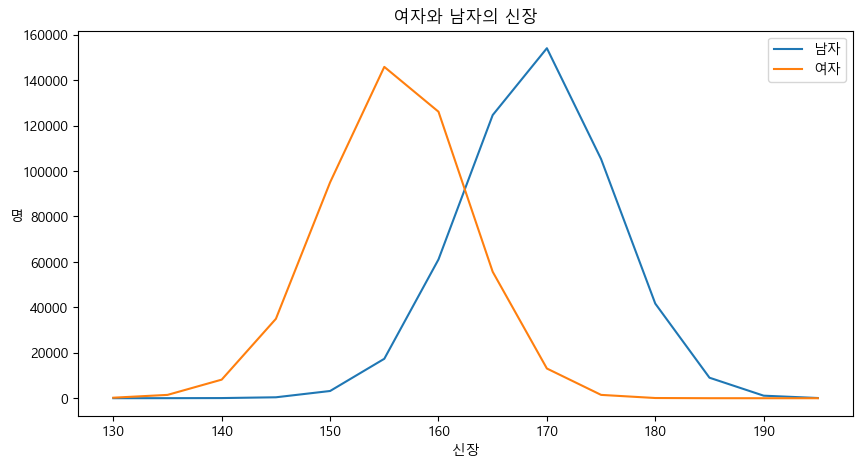

In [30]:
plt.figure(figsize=(10,5))
plt.plot(df_pivot)
plt.legend(['남자', '여자'])
plt.xlabel('신장')
plt.ylabel('명', rotation=0)
plt.title('여자와 남자의 신장')
plt.show()

# 2)  성별 키 분포 확인 

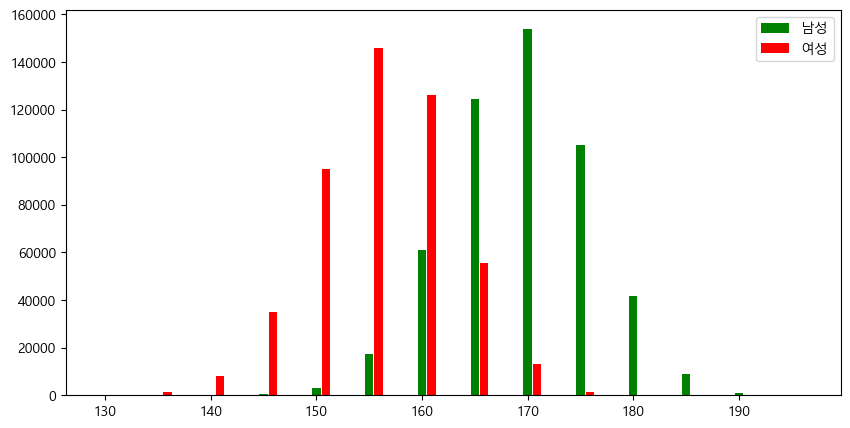

In [32]:
plt.figure(figsize=(10,5))
plt.bar(df_pivot.index, df_pivot[1], color='g', label='남성') 
plt.bar(df_pivot.index+0.9, df_pivot[2], color='r', label='여성') 
plt.legend()
plt.show()

#plt.bar() 기본 막대 너비는 width = 0.8 이다. 0.8보다 약간 크게 옆으로 이동시킴

## PyeChart로 파이 그래프 그리기

In [67]:
import pandas as pd
from pyecharts import options as opts
from pyecharts.charts import Bar, Line
from pyecharts.globals import ThemeType

labels = df_pivot.index.astype(str).tolist()
male = df_pivot[1].astype(int).tolist()
female = df_pivot[2].astype(int).tolist()

# 토탈
male_total = sum(male)
female_total = sum(female)

# 각 신장별 비율
male_pct = [round(v / male_total * 100, 2) if male_total else 0 for v in male]
female_pct = [round(v / female_total * 100, 2) if female_total else 0 for v in female]

In [64]:
male = df_pivot[1].astype(int).tolist()
print(male)

[10, 24, 68, 411, 3183, 17354, 61085, 124612, 154038, 105261, 41647, 9028, 1117, 92]


In [48]:
# [표현식 for 변수 in 반복가능객체] 리스트 컴프리헨션
# 표현식 for v in male
# (각 구간 인원수 / 남성 전체 인원수)*100 if male_total else 0 for v in male
print([round(v / male_total * 100, 2) if male_total else 0 for v in male])

[0.0, 0.0, 0.01, 0.08, 0.61, 3.35, 11.79, 24.06, 29.74, 20.32, 8.04, 1.74, 0.22, 0.02]


In [35]:
sum(female)

482070

In [62]:
bar = (
    Bar(init_opts=opts.InitOpts(theme=ThemeType.LIGHT, width="950px", height="420px", bg_color="white"))
    .add_xaxis(labels)
    .add_yaxis("남성(명)", male)
    .add_yaxis("여성(명)", female)
    .set_series_opts(
            label_opts=opts.LabelOpts(is_show=False)  # 👈 값 숨기기
        )
    .set_global_opts(
        title_opts=opts.TitleOpts(title="신장 분포 비교 (남성 vs 여성)",
                                    pos_left = "left",  # 👈 좌측 정렬
                                    pos_top = "top"),   # 👈 상단 정렬
        xaxis_opts=opts.AxisOpts(name="신장(5cm 단위)", axislabel_opts=opts.LabelOpts(rotate=0)),
        yaxis_opts=opts.AxisOpts(name="인원수(명)"),
        tooltip_opts=opts.TooltipOpts(trigger="item"),   #axis
        datazoom_opts=[opts.DataZoomOpts(type_="inside"),opts.DataZoomOpts()],
        legend_opts=opts.LegendOpts(pos_top="3%")
    )
)
bar.render_notebook()

2) ✅ (추천2) 100% 누적 막대그래프: “비율 비교” (표본수 달라도 공정)

In [68]:
bar100 = (
    Bar(init_opts=opts.InitOpts(theme=ThemeType.LIGHT, width="950px", height="420px"))
    .add_xaxis(labels)
    .add_yaxis("남성(%)", male_pct, stack="total")
    .add_yaxis("여성(%)", female_pct, stack="total")
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    .set_global_opts(
        title_opts=opts.TitleOpts(title="신장 비율 비교 (100% 누적)", pos_left="left", pos_top="top"),
        xaxis_opts=opts.AxisOpts(name="신장(5cm 단위)"),
        yaxis_opts=opts.AxisOpts(name="비율(%)", max_=100),
        tooltip_opts=opts.TooltipOpts(
            trigger="axis",
            formatter="{b}<br/>{a0}: {c0}%<br/>{a1}: {c1}%"
        ),
        datazoom_opts=[opts.DataZoomOpts(type_="inside"), opts.DataZoomOpts()],
        legend_opts=opts.LegendOpts(pos_top="3%")
    )
)
bar100.render_notebook()

In [110]:

line = (
    Line(init_opts=opts.InitOpts(theme=ThemeType.LIGHT, width="950px", height="420px"))
    .add_xaxis(labels)
    .add_yaxis("남성(%)", male_pct, is_smooth=True)
    .add_yaxis("여성(%)", female_pct, is_smooth=True)
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    .set_global_opts(
        title_opts=opts.TitleOpts(title="신장 분포 형태 비교 (비율 Line)", pos_left="left", pos_top="top"),
        xaxis_opts=opts.AxisOpts(name="신장(5cm 단위)"),
        yaxis_opts=opts.AxisOpts(name="비율(%)"),
        tooltip_opts=opts.TooltipOpts(
            trigger="item",
            formatter="{a}:{c}%"
        ),
        datazoom_opts=[opts.DataZoomOpts(type_="inside"), opts.DataZoomOpts()],
        legend_opts=opts.LegendOpts(pos_top="3%")
    )
)
line.render_notebook()

## 성별로 신장과 체중의 상관관계 분석

In [111]:
df.columns

Index(['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤',
       '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태',
       '음주여부', '구강검진수검여부', '치아우식증유무', '결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상',
       '치석'],
      dtype='str')

In [112]:
df_new2 = df[['성별코드', '신장(5cm단위)', '체중(5kg단위)']].copy()

In [113]:
df_new2.head()

,성별코드,신장(5cm단위),체중(5kg단위)
0,2,160,50
1,2,155,60
2,2,150,55
3,1,160,70
4,1,175,65


In [114]:
df_new2.tail()

,성별코드,신장(5cm단위),체중(5kg단위)
999995,2,150,45
999996,1,160,70
999997,1,160,65
999998,1,175,95
999999,1,165,55


### 2) 남자와 여자로 구분하여 데이타프레임 생성

In [115]:
df_new2.loc[:, '성별코드']

0         2
1         2
2         2
3         1
4         1
         ..
999995    2
999996    1
999997    1
999998    1
999999    1
Name: 성별코드, Length: 1000000, dtype: int64

In [116]:
#남자
df_male = df_new2[df_new2.loc[:,'성별코드']==1]
df_male

,성별코드,신장(5cm단위),체중(5kg단위)
3,1,160,70
4,1,175,65
5,1,175,80
6,1,160,60
7,1,170,65
...,...,...,...
999994,1,165,95
999996,1,160,70
999997,1,160,65
999998,1,175,95


In [117]:
# 성별의 열은 삭제한다.
df_male.drop('성별코드', axis=1, inplace=True)
df_male

,신장(5cm단위),체중(5kg단위)
3,160,70
4,175,65
5,175,80
6,160,60
7,170,65
...,...,...
999994,165,95
999996,160,70
999997,160,65
999998,175,95


In [118]:
df_male.reset_index(drop=True, inplace=True)

In [119]:
df_male.head()

,신장(5cm단위),체중(5kg단위)
0,160,70
1,175,65
2,175,80
3,160,60
4,170,65


In [120]:
df_male.tail()

,신장(5cm단위),체중(5kg단위)
517925,165,95
517926,160,70
517927,160,65
517928,175,95
517929,165,55


In [121]:
df_male.shape

(517930, 2)

In [122]:
#여성
df_female = df_new2[df_new2.loc[:,'성별코드']==2]
df_female.drop('성별코드', axis=1, inplace=True)
df_female.reset_index(drop=True, inplace=True)

In [123]:
df_female.shape

(482070, 2)

In [124]:
df_female.head()

,신장(5cm단위),체중(5kg단위)
0,160,50
1,155,60
2,150,55
3,145,60
4,155,55


In [125]:
df_male.shape, df_female.shape

((517930, 2), (482070, 2))

### 3) 상관 관계 분석

### 신장과 체중의 상관관계, 키가 크면 몸무게가 많이 나갈까?

#### 남성

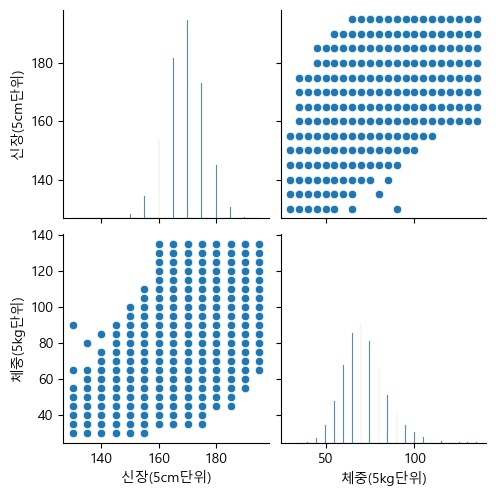

In [126]:
sns.pairplot(df_male)
plt.show()

In [127]:
#1에 가까울수록 상관관계가 높다.
df_male.corr()

,신장(5cm단위),체중(5kg단위)
신장(5cm단위),1.000000,0.530416
체중(5kg단위),0.530416,1.000000


### 여성

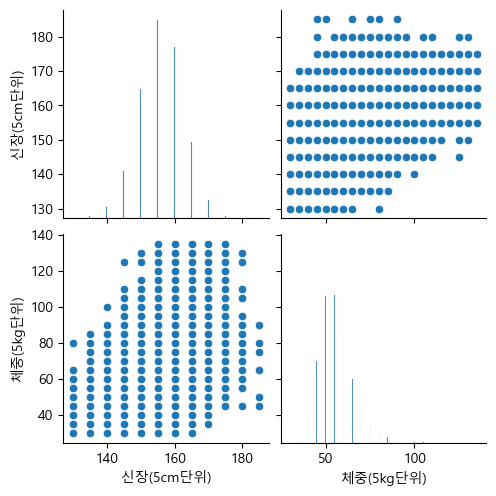

In [128]:
sns.pairplot(df_female)
plt.show()

In [129]:
df_female.corr()

,신장(5cm단위),체중(5kg단위)
신장(5cm단위),1.000000,0.326633
체중(5kg단위),0.326633,1.000000


### 성별코드사용

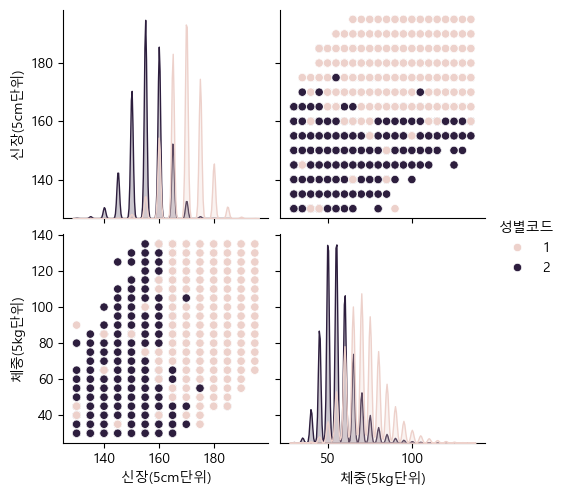

In [130]:
sns.pairplot(df_new2, hue='성별코드')
plt.show()